*****************Breast Cancer Wisconsin (Diagnostic) Dataset*****************





In [ ]:
# import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve,
                             confusion_matrix,silhouette_score)


##Step 1: ****Data Preprocessing****

---



● Load datasets.

In [ ]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')
df = X.copy()
df['target']=y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


● Handle missing values appropriately.

In [ ]:
df=df.dropna() #Handle missing values if we have
df = df.drop_duplicates() # If we have duplicates


● For the Adult dataset, encode categorical variables using suitable encoding techniques
(e.g., one-hot encoding or label encoding).

In [ ]:
print(df.dtypes)

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

I don’t need to encode categorical features for this dataset because all the features are numeric.

● Split each dataset into training and testing sets (e.g., 70% train, 30% test).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


●  standardize numerical features if required.

In [ ]:
# Standardization for supervised models
# StandardScaler fitted only on X_train, then applied to X_test
scaler_supervised = StandardScaler()
X_train = scaler_supervised.fit_transform(X_train)
X_test = scaler_supervised.transform(X_test)

# Standardization for Unsupervised Learning (K-Means & Hierarchical)
# Use the full dataset because clustering does not require labels or train/test split
scaler_unsupervised = StandardScaler()
X_scaled = scaler_unsupervised.fit_transform(X)  # full X dataset

● Data after cleaning (after Step 1)

Converting to a DataFrame allows to see all features alongside the target in a single, organized table, making it easier for viewing, or model training.

In [ ]:
df_train_scaled = pd.DataFrame(X_train, columns=X.columns)
df_train_scaled['target'] = y_train.reset_index(drop=True)
df_train_scaled

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
149,13.740,17.91,88.12,585.0,0.07944,0.06376,0.02881,0.01329,0.1473,0.05580,...,22.46,97.19,725.9,0.09711,0.18240,0.15640,0.06019,0.2350,0.07014,0.0
124,13.370,16.39,86.10,553.5,0.07115,0.07325,0.08092,0.02800,0.1422,0.05823,...,22.75,91.99,632.1,0.10250,0.25310,0.33080,0.08978,0.2048,0.07628,1.0
421,14.690,13.98,98.22,656.1,0.10310,0.18360,0.14500,0.06300,0.2086,0.07406,...,18.34,114.10,809.2,0.13120,0.36350,0.32190,0.11080,0.2827,0.09208,NaN
195,12.910,16.33,82.53,516.4,0.07941,0.05366,0.03873,0.02377,0.1829,0.05667,...,22.00,90.81,600.6,0.10970,0.15060,0.17640,0.08235,0.3024,0.06949,1.0
545,13.620,23.23,87.19,573.2,0.09246,0.06747,0.02974,0.02443,0.1664,0.05801,...,29.09,97.58,729.8,0.12160,0.15170,0.10490,0.07174,0.2642,0.06953,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,...,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840,0.0
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,...,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097,1.0
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,...,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120,0.0
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,...,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550,NaN


##Step 2: ****Model Building****

---

##Train at least two SVM classifiers:

●  One with a linear kernel.

In [ ]:
# Train SVM with linear kernel
svm_linear = SVC(kernel='linear',probability=True)
svm_linear.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

● one with a non-linear kernel (e.g., RBF or polynomial).

In [ ]:
 # Train SVM with RBF (non-linear) kernel
svm_rbf = SVC(kernel='rbf',probability=True)
svm_rbf.fit(X_train, y_train)

SVC(probability=True)

●  K-Means Clustering

◆ Apply K-Means with K = 2.
◆ Use the scaled features (no labels when fitting).

In [ ]:
# Train Kmeans
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

● Hierarchical Clustering

◆ Apply Hierarchical clustering with at least two linkage methods (e.g., single,
complete, average).

In [ ]:
# List of linkage methods
linkage_methods = ['single', 'complete', 'average']

# Dictionary to store labels
hc_labels_dict = {}

# Build models
for method in linkage_methods:
    hc = AgglomerativeClustering(n_clusters=2, linkage=method)
    labels = hc.fit_predict(X_scaled)  # fit and predict clusters
    hc_labels_dict[method] = labels  # store the cluster labels

##Step 3: ****Model Evaluation and Visualization****

A. SVM Evaluation (Supervised)

● ○ Predict class labels.

In [ ]:

y_pred_linear = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)

● Compute and report the following metrics for both models on each dataset:
○ Accuracy
○ Precision
○ Recall
○ F1-Score
○ ROC-AUC Score

In [ ]:
#  probabilities for ROC-AUC
y_prob_linear = svm_linear.predict_proba(X_test)[:, 1]
y_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]

# Function to evaluation metrics
def print_metrics(y_true, y_pred, y_prob, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-Score:", f1_score(y_true, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_true, y_prob))
    print()
# Print metrics for models

print_metrics(y_test, y_pred_linear, y_prob_linear, "Linear SVM")
print_metrics(y_test, y_pred_rbf, y_prob_rbf, "RBF SVM")

--- Linear SVM ---
Accuracy: 0.9649122807017544
Precision: 0.9636363636363636
Recall: 0.9814814814814815
F1-Score: 0.9724770642201835
ROC-AUC Score: 0.9964726631393298

--- RBF SVM ---
Accuracy: 0.935672514619883
Precision: 0.907563025210084
Recall: 1.0
F1-Score: 0.9515418502202643
ROC-AUC Score: 0.9930922986478543



## Tune basic hyperparameters For SVM

 Tune basic hyperparameters (e.g., C, gamma, degree if polynomial). You can use
simple manual tuning or GridSearchCV/RandomizedSearchCV.

In [ ]:
# ===== Linear SVM Tuning =====
param_linear = {
    'C': [0.1, 1, 10, 100]
}

grid_linear = GridSearchCV(SVC(kernel='linear', probability=True),
                           param_linear, cv=5)
grid_linear.fit(X_train, y_train)

best_linear = grid_linear.best_estimator_
y_pred_linear_tuned = best_linear.predict(X_test)
y_prob_linear_tuned = best_linear.predict_proba(X_test)[:, 1]

print("Best Linear SVM params:", grid_linear.best_params_)
print_metrics(y_test, y_pred_linear_tuned, y_prob_linear_tuned,
              "Linear SVM (Tuned)")

Best Linear SVM params: {'C': 10}
--- Linear SVM (Tuned) ---
Accuracy: 0.9707602339181286
Precision: 0.9813084112149533
Recall: 0.9722222222222222
F1-Score: 0.9767441860465116
ROC-AUC Score: 0.9932392710170488



In [ ]:
# ===== RBF SVM Tuning =====
param_rbf = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 0.1, 0.01, 0.001]
}

grid_rbf = GridSearchCV(SVC(kernel='rbf', probability=True),
                        param_rbf, cv=5)
grid_rbf.fit(X_train, y_train)

best_rbf = grid_rbf.best_estimator_
y_pred_rbf_tuned = best_rbf.predict(X_test)
y_prob_rbf_tuned = best_rbf.predict_proba(X_test)[:, 1]

print("Best RBF SVM params:", grid_rbf.best_params_)
print_metrics(y_test, y_pred_rbf_tuned, y_prob_rbf_tuned,
              "RBF SVM (Tuned)")

Best RBF SVM params: {'C': 50, 'gamma': 'scale'}
--- RBF SVM (Tuned) ---
Accuracy: 0.9649122807017544
Precision: 0.9553571428571429
Recall: 0.9907407407407407
F1-Score: 0.9727272727272728
ROC-AUC Score: 0.9979423868312758





**Thus, we can see that hyperparameter tuning improved the accuracy and overall performance.**


I used GridSearchCV because it systematically tests all hyperparameter combinations and automatically selects the best one.

● Plot ROC curves for both models on each dataset, overlaying them for direct
comparison.

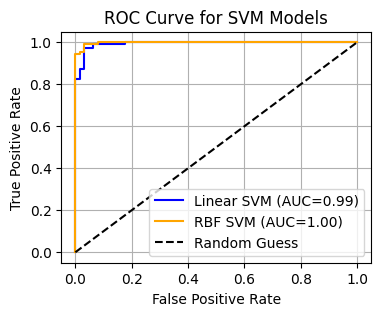

In [ ]:
# False Positive Rate & True Positive Rate
fpr_linear_svm, tpr_linear_svm, _ = roc_curve(y_test, y_prob_linear_tuned)
fpr_rbf_svm, tpr_rbf_svm, _ = roc_curve(y_test, y_prob_rbf_tuned)

# Plot ROC Curve
plt.figure(figsize=(4,3))
plt.plot(fpr_linear_svm, tpr_linear_svm, label=f'Linear SVM (AUC={roc_auc_score(y_test, y_prob_linear_tuned):.2f})', color='blue')
plt.plot(fpr_rbf_svm, tpr_rbf_svm, label=f'RBF SVM (AUC={roc_auc_score(y_test, y_prob_rbf_tuned):.2f})', color='orange')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

● Generate and analyse confusion matrices for each model and dataset

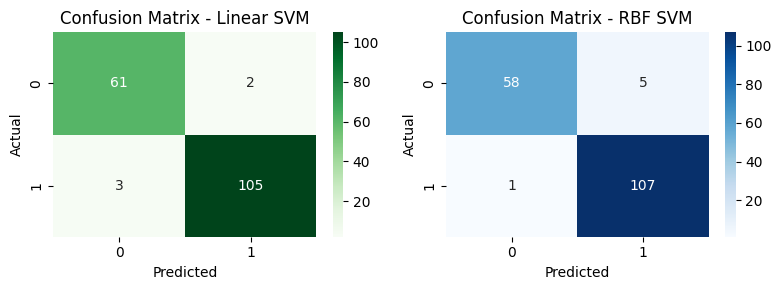

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(8,3))

# Linear SVM
cm_linear_svm = confusion_matrix(y_test, y_pred_linear_tuned)
sns.heatmap(cm_linear_svm, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Confusion Matrix - Linear SVM')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# RBF SVM
cm_rbf_svm = confusion_matrix(y_test, y_pred_rbf_tuned)
sns.heatmap(cm_rbf_svm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix - RBF SVM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


----------------------------------------
B. Clustering Evaluation (Unsupervised)

In [ ]:
# Silhouette Score for K-Means
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
print(f'Silhouette Score (K-Means): {sil_kmeans:.3f}')

# Table comparing K-Means clusters vs true labels
cm_kmeans = pd.crosstab(kmeans_labels, y)
print('\nK-Means Clusters vs True Labels:\n', cm_kmeans)


Silhouette Score (K-Means): 0.345

K-Means Clusters vs True Labels:
 target    0    1
row_0           
0       175   13
1        37  344


In [ ]:
# Evaluate Hierarchical Clustering
for method in linkage_methods:
    labels = hc_labels_dict[method]
    # Silhouette Score
    sil = silhouette_score(X_scaled, labels)
    print(f'Silhouette Score ({method} linkage): {sil:.3f}')
    # Table comparing clusters vs true labels
    cm_hc = pd.crosstab(labels, y)
    print(f'\nHierarchical Clusters ({method} linkage) vs True Labels:\n', cm_hc)

Silhouette Score (single linkage): 0.661

Hierarchical Clusters (single linkage) vs True Labels:
 target    0    1
row_0           
0       210  357
1         2    0
Silhouette Score (complete linkage): 0.661

Hierarchical Clusters (complete linkage) vs True Labels:
 target    0    1
row_0           
0       210  357
1         2    0
Silhouette Score (average linkage): 0.634

Hierarchical Clusters (average linkage) vs True Labels:
 target    0    1
row_0           
0       209  357
1         3    0


K-Means was the worst compared to Hierarchical, showing a very low Silhouette score (0.345) and poorly structured clusters, while Hierarchical achieved higher Silhouette scores (0.634–0.661) and better class separation. However, both are still worse than SVM for predicting the true labels and accurately separating classes, as SVM learns directly from the labeled data.

◆ plot a dendrogram and show how decide the
number of clusters.

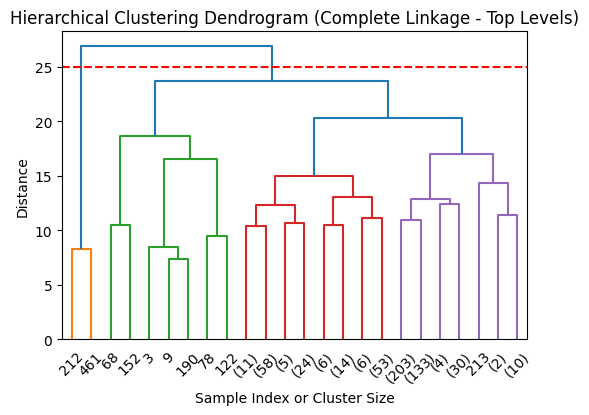

In [ ]:
linked = linkage(X_scaled, method='complete')

plt.figure(figsize=(6,4))

#plot dendrogram
dendrogram(
    linked,
    truncate_mode='level',
    p=5,
    leaf_rotation=45,
    leaf_font_size=10
)
# Cut level showing the separation into 2 clusters
plt.axhline(y=25, color='red', linestyle='--')

plt.title('Hierarchical Clustering Dendrogram (Complete Linkage - Top Levels)')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')
plt.show()


• Use PCA to 2D and plot:

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


 Data colored by true labels

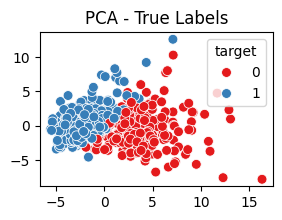

In [ ]:
plt.figure(figsize=(3,2))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1', s=50)
plt.title('PCA - True Labels')
plt.show()


 Data colored by K-Means clusters


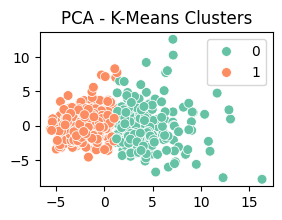

In [ ]:
plt.figure(figsize=(3,2))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette='Set2', s=50)
plt.title('PCA - K-Means Clusters')
plt.show()


Data colored by Hierarchical clusters

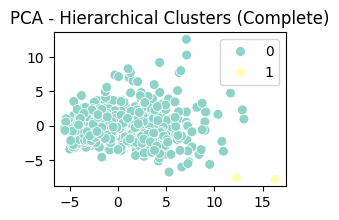

In [ ]:
plt.figure(figsize=(3,2))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hc_labels_dict['complete'], palette='Set3', s=50)
plt.title('PCA - Hierarchical Clusters (Complete)')
plt.show()


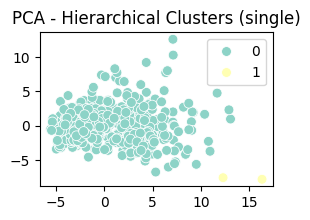

In [ ]:
plt.figure(figsize=(3,2))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hc_labels_dict['single']
                , palette='Set3', s=50)
plt.title('PCA - Hierarchical Clusters (single)')
plt.show()